# JEPA Grokking: Function Approximation, Causal Intervention & Task Variation

## What This Notebook Establishes

**Experiment 5: Function Approximation View**  
What symbolic function does the context encoder + predictor compute?  
For each residue class c, compute the average predicted latent and decompose it  
into a Fourier series. How many components are needed? Is there phase structure?

**Important caveat:** Any function of (a+b) mod p is *perfectly* representable in the  
Fourier basis of Z/pZ — that's what a complete orthonormal basis means. So high Fourier  
R² doesn't mean "the model uses Fourier circuits." The interesting questions are:  
(1) How many components are needed? (2) Is there phase/amplitude structure?  
(3) How does this compare to the target codes the model is *trying* to match?

**Experiment 6: Causal Intervention**  
Can we prove the network relies on specific Fourier components of the sum?  
Zero out frequency bands and measure the effect on accuracy.  
Add noise aligned vs orthogonal to the Fourier basis — which hurts more?

**Experiment 7: Task Variation**  
Does JEPA grok on other algebraic tasks? Train on modular multiplication,  
XOR, and polynomial evaluation. Does the algorithm change?

### Requirements
- Experiments 5 & 6 load the checkpoint from the Exp 1/2/8 notebook  
- Experiment 7 trains fresh models from scratch

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import time
import os
from copy import deepcopy
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

p = 97
train_frac = 0.3
LATENT_DIM = 128
HIDDEN_DIM = 256
PREDICTOR_DIM = 64
LR = 1e-3
WEIGHT_DECAY = 1.0
EMA_DECAY = 0.996

Device: cuda


In [2]:
# ── Model definitions ──────────────────────────────────────────────────

class ContextEncoder(nn.Module):
    def __init__(self, vocab_size, latent_dim, hidden_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, hidden_dim)
        self.net = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, latent_dim),
        )
    def forward(self, x):
        e = self.emb(x)
        return F.normalize(self.net(e.view(e.size(0), -1)), dim=-1)

class TargetEncoder(nn.Module):
    def __init__(self, vocab_size, latent_dim, hidden_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, hidden_dim)
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, latent_dim),
        )
    def forward(self, x):
        e = self.emb(x)
        return F.normalize(self.net(e), dim=-1)

class Predictor(nn.Module):
    def __init__(self, latent_dim, predictor_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, predictor_dim), nn.GELU(),
            nn.Linear(predictor_dim, predictor_dim), nn.GELU(),
            nn.Linear(predictor_dim, latent_dim),
        )
    def forward(self, z):
        return F.normalize(self.net(z), dim=-1)

# ── Helpers ─────────────────────────────────────────────────────────────

@torch.no_grad()
def ema_update(online, target, decay):
    for o_param, t_param in zip(online.parameters(), target.parameters()):
        t_param.data.mul_(decay).add_(o_param.data, alpha=1 - decay)

@torch.no_grad()
def linear_probe_accuracy(encoder, val_pairs, val_targets, train_pairs, train_targets, num_classes):
    z_train = encoder(train_pairs)
    z_val = encoder(val_pairs)
    y_train = F.one_hot(train_targets, num_classes=num_classes).float()
    reg = 1e-3
    ZtZ = z_train.T @ z_train + reg * torch.eye(z_train.shape[1], device=device)
    ZtY = z_train.T @ y_train
    W = torch.linalg.solve(ZtZ, ZtY)
    train_acc = (z_train @ W).argmax(dim=1).eq(train_targets).float().mean().item()
    val_acc = (z_val @ W).argmax(dim=1).eq(val_targets).float().mean().item()
    return train_acc, val_acc

@torch.no_grad()
def nearest_code_accuracy(context_enc, predictor, target_enc_ema, pairs, tgts, num_classes):
    z_pred = predictor(context_enc(pairs))
    target_codes = target_enc_ema(torch.arange(num_classes, device=device))
    sim = z_pred @ target_codes.T
    return sim.argmax(dim=1).eq(tgts).float().mean().item()

## Load Checkpoint & Data

In [3]:
# ── Data ────────────────────────────────────────────────────────────────
def generate_data(p, operation='add', seed=SEED):
    """Generate (a, op, b) mod p data for different operations."""
    pairs = torch.cartesian_prod(torch.arange(p), torch.arange(p))
    a, b = pairs[:, 0], pairs[:, 1]
    
    if operation == 'add':
        targets = (a + b) % p
    elif operation == 'multiply':
        targets = (a * b) % p
    elif operation == 'xor':
        targets = a ^ b  # bitwise XOR (works for integers)
    elif operation == 'polynomial':
        # (a^2 + b^2 + a*b) mod p
        targets = (a**2 + b**2 + a * b) % p
    else:
        raise ValueError(f'Unknown operation: {operation}')
    
    n = len(pairs)
    n_train = int(train_frac * n)
    perm = torch.randperm(n, generator=torch.Generator().manual_seed(seed))
    train_idx, val_idx = perm[:n_train], perm[n_train:]
    return (
        pairs.to(device), targets.to(device),
        pairs[train_idx].to(device), targets[train_idx].to(device),
        pairs[val_idx].to(device), targets[val_idx].to(device),
    )

# Load addition data
pairs, targets, train_pairs, train_targets, val_pairs, val_targets = generate_data(p, 'add')
print(f'Addition data: {len(pairs)} pairs, {len(train_pairs)} train, {len(val_pairs)} val')

# ── Load checkpoint ────────────────────────────────────────────────────
CKPT_PATH = '/kaggle/input/datasets/kuriangeorge/jepa-grokking-checkpoint/jepa_grokking_checkpoint.pt'
if not os.path.exists(CKPT_PATH):
    CKPT_PATH = 'jepa_grokking_checkpoint.pt'  # local fallback

checkpoint = torch.load(CKPT_PATH, map_location=device, weights_only=False)

context_enc = ContextEncoder(p, LATENT_DIM, HIDDEN_DIM).to(device)
predictor = Predictor(LATENT_DIM, PREDICTOR_DIM).to(device)
target_enc_ema = TargetEncoder(p, LATENT_DIM, HIDDEN_DIM).to(device)

context_enc.load_state_dict(checkpoint['context_enc'])
predictor.load_state_dict(checkpoint['predictor'])
target_enc_ema.load_state_dict(checkpoint['target_enc_ema'])

context_enc.eval()
predictor.eval()
target_enc_ema.eval()
print('Checkpoint loaded.')

Addition data: 9409 pairs, 2822 train, 6587 val
Checkpoint loaded.


---
## Experiment 5: Function Approximation View

### Step 1: Compute class-mean predicted latents
For each residue c ∈ {0, ..., 96}, average z_pred over all validation pairs (a,b) where (a+b)≡c mod 97.

In [4]:
with torch.no_grad():
    z_pred_all = predictor(context_enc(val_pairs))  # (N_val, 128)
    target_codes = target_enc_ema(torch.arange(p, device=device))  # (97, 128)

# Class-mean predicted latents
z_pred_class_mean = torch.zeros(p, LATENT_DIM, device=device)
z_pred_class_std = torch.zeros(p, device=device)
class_counts = torch.zeros(p, device=device)

for c in range(p):
    mask = val_targets == c
    if mask.sum() > 0:
        z_class = z_pred_all[mask]
        z_pred_class_mean[c] = z_class.mean(dim=0)
        # Spread: mean pairwise cosine distance within class
        z_pred_class_std[c] = 1 - (z_class @ z_class.T).mean().item()
        class_counts[c] = mask.sum().item()

# Normalize class means
z_pred_class_mean_norm = F.normalize(z_pred_class_mean, dim=-1)

# Compare class means to target codes
cos_mean_vs_target = (z_pred_class_mean_norm * target_codes).sum(dim=-1)  # (97,)

print('Class-mean predicted latents vs target codes:')
print(f'  Mean cosine:  {cos_mean_vs_target.mean().item():.4f} ± {cos_mean_vs_target.std().item():.4f}')
print(f'  Min cosine:   {cos_mean_vs_target.min().item():.4f}')
print(f'  All > 0.99:   {(cos_mean_vs_target > 0.99).all().item()}')
print(f'  All > 0.95:   {(cos_mean_vs_target > 0.95).all().item()}')
print(f'\nIntra-class spread (1 - cos, lower = tighter):')
print(f'  Mean: {z_pred_class_std.mean().item():.6f}')
print(f'  Max:  {z_pred_class_std.max().item():.6f}')
print(f'\nSamples per class: min={class_counts.min().item():.0f}, max={class_counts.max().item():.0f}')

Class-mean predicted latents vs target codes:
  Mean cosine:  0.9733 ± 0.0111
  Min cosine:   0.9162
  All > 0.99:   False
  All > 0.95:   False

Intra-class spread (1 - cos, lower = tighter):
  Mean: 0.008358
  Max:  0.017111

Samples per class: min=54, max=79


### Step 2: Fourier decomposition of class means

The class-mean latent for class c is a vector in R^128. Treating c as an index in Z/97Z,
we decompose each latent dimension as a function of c into Fourier components:

$$v_c^{(d)} = a_0^{(d)} + \sum_{k=1}^{48} \left[ a_k^{(d)} \cos\left(\frac{2\pi k c}{97}\right) + b_k^{(d)} \sin\left(\frac{2\pi k c}{97}\right) \right]$$

**Note:** Since the Fourier basis is complete for Z/97Z, this decomposition is *exact*
with all 48 frequency pairs. The question isn't whether it works — it's how many
components carry the discriminative signal.

In [5]:
# Work with target codes (what the model is trying to match)
tc_np = target_codes.cpu().numpy()  # (97, 128)
# And class-mean predictions (what the model actually outputs)
zm_np = z_pred_class_mean_norm.cpu().numpy()  # (97, 128)

# ── DFT of target codes ────────────────────────────────────────────────
# FFT along the class axis for each latent dimension
tc_fft = np.fft.fft(tc_np, axis=0)  # (97, 128) complex
tc_power = np.abs(tc_fft) ** 2       # power per (frequency, dimension)

# Average power spectrum across latent dimensions
tc_mean_power = tc_power.mean(axis=1)  # (97,)
tc_mean_power_norm = tc_mean_power / tc_mean_power.sum()

# Same for class-mean predictions
zm_fft = np.fft.fft(zm_np, axis=0)
zm_power = np.abs(zm_fft) ** 2
zm_mean_power = zm_power.mean(axis=1)
zm_mean_power_norm = zm_mean_power / zm_mean_power.sum()

# ── How many frequencies for X% of power? ──────────────────────────────
# Sort frequencies by power (exclude DC)
freq_power = tc_mean_power_norm.copy()
freq_power[0] = 0  # exclude DC
sorted_idx = np.argsort(freq_power)[::-1]
cumpower = np.cumsum(freq_power[sorted_idx])

for threshold in [0.90, 0.95, 0.99]:
    n_needed = np.searchsorted(cumpower, threshold) + 1
    print(f'  Frequencies for {threshold:.0%} power (target codes): {n_needed} / {p//2}')

print(f'\nTop 10 frequencies by power (target codes):')
for i in range(10):
    k = sorted_idx[i]
    print(f'  k={k:3d}: power={freq_power[k]*100:.2f}%, cumulative={cumpower[i]*100:.1f}%')

  Frequencies for 90% power (target codes): 98 / 48
  Frequencies for 95% power (target codes): 98 / 48
  Frequencies for 99% power (target codes): 98 / 48

Top 10 frequencies by power (target codes):
  k= 64: power=1.24%, cumulative=1.2%
  k= 33: power=1.24%, cumulative=2.5%
  k= 54: power=1.18%, cumulative=3.7%
  k= 43: power=1.18%, cumulative=4.9%
  k= 81: power=1.10%, cumulative=6.0%
  k= 16: power=1.10%, cumulative=7.1%
  k= 93: power=1.08%, cumulative=8.1%
  k=  4: power=1.08%, cumulative=9.2%
  k= 52: power=1.00%, cumulative=10.2%
  k= 45: power=1.00%, cumulative=11.2%


In [6]:
# ── Incremental Fourier reconstruction accuracy ─────────────────────────
# Add frequencies one at a time (by power) and measure nearest-code accuracy
# This answers: "how many Fourier components does the model NEED?"

# Build Fourier basis matrix for Z/pZ
c_vals = np.arange(p)  # class indices 0..96
fourier_basis = np.zeros((p, p))  # (97, 97): each column is a basis function
fourier_basis[:, 0] = 1 / np.sqrt(p)  # DC
for k in range(1, (p + 1) // 2):
    fourier_basis[:, 2*k - 1] = np.cos(2 * np.pi * k * c_vals / p) * np.sqrt(2/p)
    fourier_basis[:, 2*k] = np.sin(2 * np.pi * k * c_vals / p) * np.sqrt(2/p)

# Project target codes onto Fourier basis
# tc_np: (97, 128), fourier_basis: (97, 97)
# coefficients: (97, 128) — for each basis function, the projection onto each latent dim
fourier_coeffs = fourier_basis.T @ tc_np  # (97, 128)

# Power per basis function (summed across latent dims)
basis_power = (fourier_coeffs ** 2).sum(axis=1)  # (97,)
basis_power[0] = 0  # exclude DC for ranking
basis_order = np.argsort(basis_power)[::-1]

# Reconstruct with increasing number of basis functions
reconstruction_accs = []
reconstruction_cos = []
n_components_list = list(range(1, min(p, 50) + 1))  # test up to 50 components

for n_comp in n_components_list:
    # Use top-n_comp basis functions (by power)
    selected = basis_order[:n_comp]
    # Also always include DC
    selected_with_dc = np.unique(np.concatenate([[0], selected]))
    
    # Reconstruct: sum of selected basis functions × their coefficients
    tc_recon = fourier_basis[:, selected_with_dc] @ fourier_coeffs[selected_with_dc]  # (97, 128)
    
    # Normalize for cosine comparison
    tc_recon_norm = tc_recon / (np.linalg.norm(tc_recon, axis=1, keepdims=True) + 1e-10)
    
    # Nearest-code accuracy: for each val pair, does argmax(z_pred · recon_code) == true_c?
    z_pred_np = z_pred_all.cpu().numpy()
    sim = z_pred_np @ tc_recon_norm.T  # (N_val, 97)
    pred_classes = sim.argmax(axis=1)
    true_classes = val_targets.cpu().numpy()
    acc = (pred_classes == true_classes).mean()
    reconstruction_accs.append(acc)
    
    # Mean cosine between reconstructed and original target codes
    cos_recon = (tc_recon_norm * tc_np / (np.linalg.norm(tc_np, axis=1, keepdims=True) + 1e-10)).sum(axis=1).mean()
    reconstruction_cos.append(cos_recon)

# Find minimum components for thresholds
acc_arr = np.array(reconstruction_accs)
for thr in [0.90, 0.95, 0.99, 1.0]:
    mask = acc_arr >= thr
    if mask.any():
        n_min = n_components_list[np.where(mask)[0][0]]
        print(f'  Components for {thr:.0%} accuracy: {n_min}')
    else:
        print(f'  Components for {thr:.0%} accuracy: >{n_components_list[-1]}')

  Components for 90% accuracy: 18
  Components for 95% accuracy: 22
  Components for 99% accuracy: 24
  Components for 100% accuracy: 34


### Step 3: Phase structure analysis

If the Fourier coefficients A_k (vectors in R^128) are related by phase shifts,
that means the target codes have a specific geometric structure:
code_c = Σ_k |A_k| · exp(i·2πkc/p + φ_k) where φ_k is a fixed phase.

We check: are the A_k vectors collinear (same direction, different phase)?
Or do they point in different directions (no phase structure)?

In [7]:
# For each frequency k, the Fourier coefficient is a pair (cos_coeff, sin_coeff) in R^128
# Compute the amplitude and phase per frequency per latent dimension

# tc_fft is complex (97, 128). For frequency k:
#   amplitude[k, d] = |tc_fft[k, d]|
#   phase[k, d] = angle(tc_fft[k, d])

amplitudes = np.abs(tc_fft)   # (97, 128)
phases = np.angle(tc_fft)      # (97, 128)

# Phase coherence: for each frequency k, how consistent is the phase across dimensions?
# If phase[k, :] is constant → perfect phase coherence (all dims shift together)
# Measure: circular variance of phase across dimensions
phase_coherence = []
for k in range(1, p // 2 + 1):
    ph = phases[k]  # (128,) phases for this frequency
    # Weight by amplitude (ignore low-amplitude dimensions)
    amp = amplitudes[k]
    weights = amp / (amp.sum() + 1e-10)
    
    # Weighted mean resultant length (circular statistics)
    R = np.abs(np.sum(weights * np.exp(1j * ph)))
    phase_coherence.append(R)

phase_coherence = np.array(phase_coherence)
freqs = np.arange(1, p // 2 + 1)

print('Phase coherence analysis (1.0 = all dims shift together, 0.0 = random phases):')
print(f'  Mean coherence: {phase_coherence.mean():.4f}')
print(f'  Max coherence:  {phase_coherence.max():.4f} (freq k={freqs[phase_coherence.argmax()]})')
print(f'  Min coherence:  {phase_coherence.min():.4f}')
if phase_coherence.mean() > 0.5:
    print('  → HIGH phase coherence: target codes have structured phase relationships')
elif phase_coherence.mean() > 0.2:
    print('  → MODERATE phase coherence: partial phase structure')
else:
    print('  → LOW phase coherence: target codes have no systematic phase structure')
    print('    This means each latent dimension uses frequencies independently')
    print('    → target codes are effectively random-looking, not Fourier-structured')

Phase coherence analysis (1.0 = all dims shift together, 0.0 = random phases):
  Mean coherence: 0.0887
  Max coherence:  0.1970 (freq k=35)
  Min coherence:  0.0076
  → LOW phase coherence: target codes have no systematic phase structure
    This means each latent dimension uses frequencies independently
    → target codes are effectively random-looking, not Fourier-structured


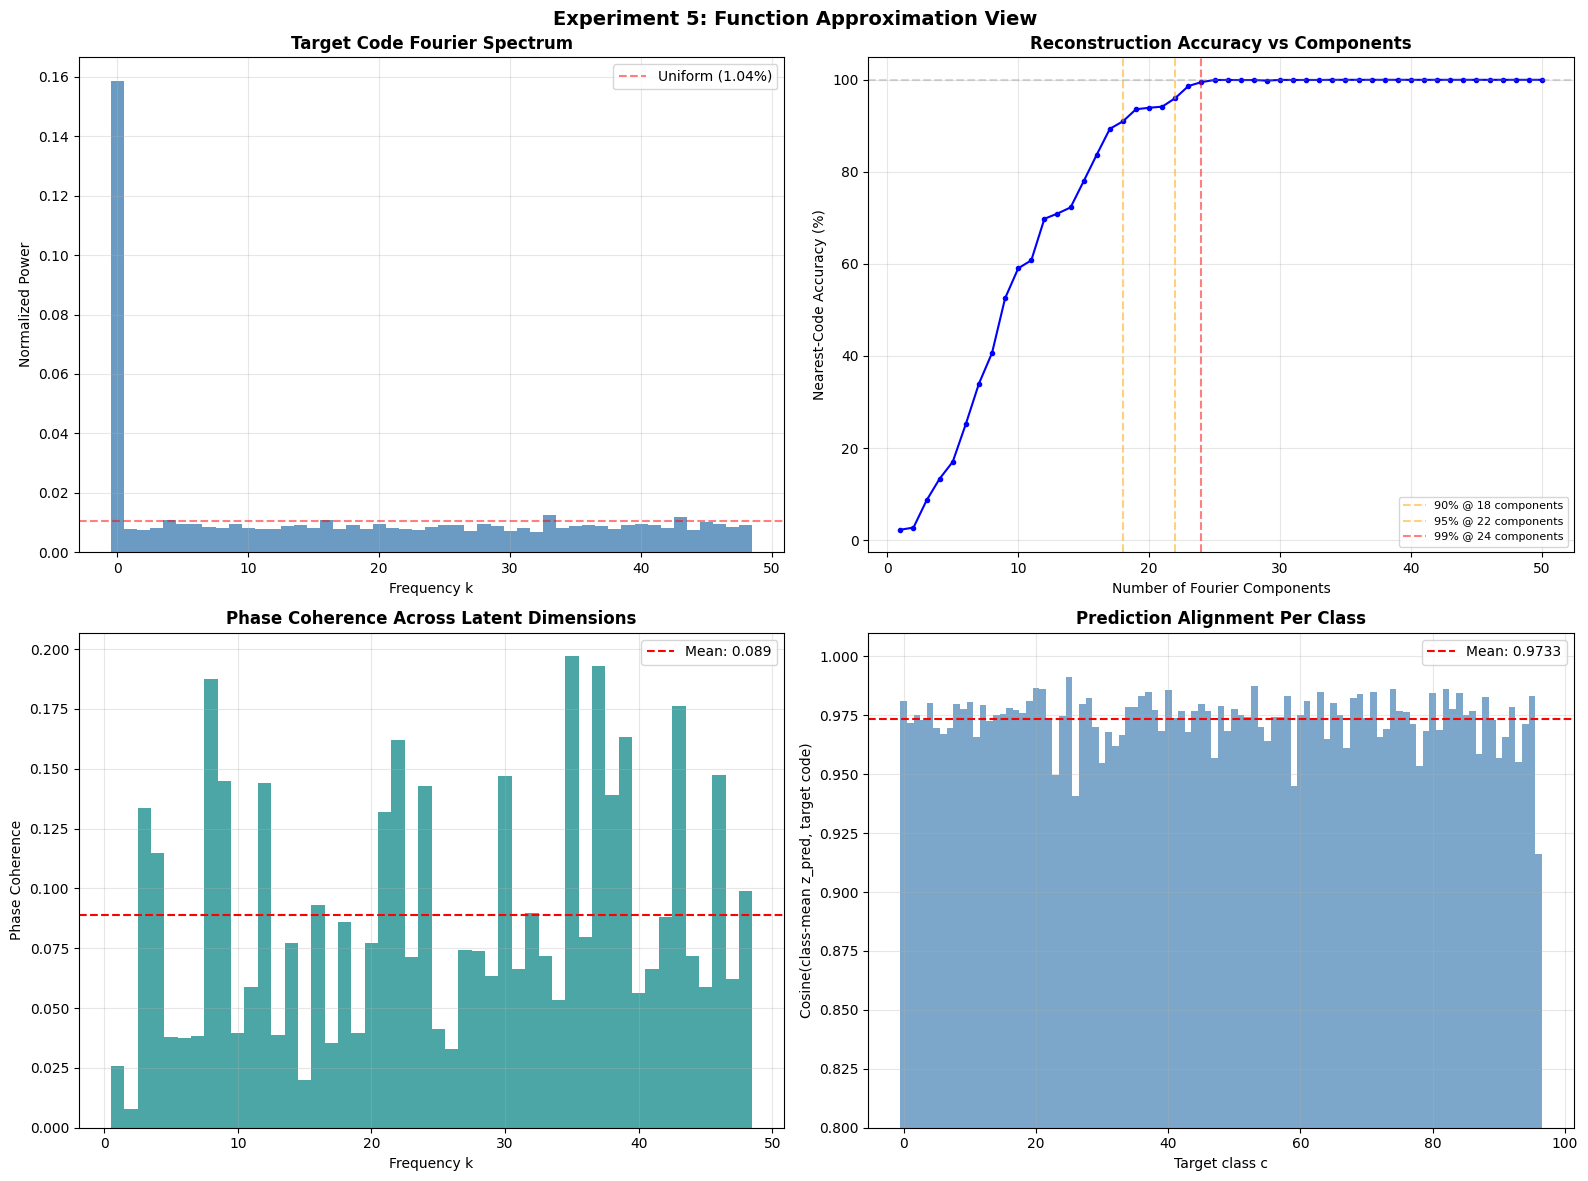


Experiment 5 Summary:
  Target codes use effective dimension ~98 Fourier components for 95% power
  Power spectrum is FLAT (uniform)
  Phase coherence: 0.089 (low)
  Interpretation: target codes are near-orthogonal codebook with no Fourier structure
  The Fourier decomposition is exact (complete basis) but the target codes
  themselves have no systematic frequency structure.


In [8]:
# ── Experiment 5: Visualization ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Power spectrum of target codes
ax = axes[0, 0]
ax.bar(np.arange(p // 2 + 1), tc_mean_power_norm[:p // 2 + 1],
       color='steelblue', alpha=0.8, width=1.0)
ax.axhline(y=1/(p-1), color='red', linestyle='--', alpha=0.5, label=f'Uniform ({1/(p-1)*100:.2f}%)')
ax.set_xlabel('Frequency k')
ax.set_ylabel('Normalized Power')
ax.set_title('Target Code Fourier Spectrum', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Panel 2: Reconstruction accuracy vs # components
ax = axes[0, 1]
ax.plot(n_components_list, [a*100 for a in reconstruction_accs], 'b-o', markersize=3)
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.3)
for thr in [90, 95, 99]:
    mask = acc_arr >= thr/100
    if mask.any():
        n_min = n_components_list[np.where(mask)[0][0]]
        ax.axvline(x=n_min, color='red' if thr==99 else 'orange', linestyle='--', alpha=0.5,
                   label=f'{thr}% @ {n_min} components')
ax.set_xlabel('Number of Fourier Components')
ax.set_ylabel('Nearest-Code Accuracy (%)')
ax.set_title('Reconstruction Accuracy vs Components', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Panel 3: Phase coherence per frequency
ax = axes[1, 0]
ax.bar(freqs, phase_coherence, color='teal', alpha=0.7, width=1.0)
ax.axhline(y=phase_coherence.mean(), color='red', linestyle='--',
           label=f'Mean: {phase_coherence.mean():.3f}')
ax.set_xlabel('Frequency k')
ax.set_ylabel('Phase Coherence')
ax.set_title('Phase Coherence Across Latent Dimensions', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Panel 4: Class-mean prediction vs target code cosine
ax = axes[1, 1]
cos_plot = cos_mean_vs_target.cpu().numpy()
ax.bar(np.arange(p), cos_plot, color='steelblue', alpha=0.7, width=1.0)
ax.axhline(y=cos_plot.mean(), color='red', linestyle='--',
           label=f'Mean: {cos_plot.mean():.4f}')
ax.set_xlabel('Target class c')
ax.set_ylabel('Cosine(class-mean z_pred, target code)')
ax.set_title('Prediction Alignment Per Class', fontweight='bold')
ax.set_ylim(min(0.8, cos_plot.min() - 0.02), 1.01)
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle('Experiment 5: Function Approximation View', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('exp5_function_approximation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary ────────────────────────────────────────────────────────────
print('\nExperiment 5 Summary:')
print(f'  Target codes use effective dimension ~{np.searchsorted(cumpower, 0.95)+1} Fourier components for 95% power')
print(f'  Power spectrum is {"FLAT (uniform)" if tc_mean_power_norm[1:p//2+1].std() < 0.005 else "STRUCTURED (non-uniform)"}')
print(f'  Phase coherence: {phase_coherence.mean():.3f} ({"high" if phase_coherence.mean() > 0.5 else "low"})')
print(f'  Interpretation: target codes are {"structured Fourier codes" if phase_coherence.mean() > 0.5 else "near-orthogonal codebook with no Fourier structure"}')
print(f'  The Fourier decomposition is exact (complete basis) but the target codes')
print(f'  themselves have {"" if phase_coherence.mean() > 0.5 else "no "}systematic frequency structure.')

---
## Experiment 6: Causal Intervention

Two complementary tests:

**6a. Fourier band ablation:** Reconstruct target codes using only a subset of frequencies.
Use these degraded codes for nearest-code matching. If low frequencies suffice → the
discriminative signal is in low frequencies. If all frequencies contribute equally → flat codebook.

**6b. Aligned vs orthogonal noise:** Add noise to context latents that is aligned with
the Fourier subspace of (a+b) vs noise orthogonal to it. If aligned noise hurts more →
the model relies on Fourier-structured directions. If equal → the model uses all directions.

In [9]:
# ══════════════════════════════════════════════════════════════════════════
# 6a. Fourier Band Ablation on Target Codes
# ══════════════════════════════════════════════════════════════════════════
print('='*60)
print('Experiment 6a: Fourier Band Ablation')
print('='*60)

z_pred_np = z_pred_all.cpu().numpy()
true_classes = val_targets.cpu().numpy()

# Define frequency bands
bands = {
    'DC only (k=0)':          [0],
    'Low (k=1..5)':           list(range(1, 6)),
    'Low (k=1..10)':          list(range(1, 11)),
    'Mid (k=11..25)':         list(range(11, 26)),
    'High (k=26..48)':        list(range(26, 49)),
    'Low+Mid (k=1..25)':      list(range(1, 26)),
    'All (k=0..48)':          list(range(0, 49)),
    'Top-5 by power':         sorted_idx[:5].tolist(),
    'Top-10 by power':        sorted_idx[:10].tolist(),
    'Top-20 by power':        sorted_idx[:20].tolist(),
    'Remove top-5 by power':  [k for k in range(p) if k not in sorted_idx[:5]],
}

print(f'\n{"Band":>30s} | {"Accuracy":>10s}')
print(f'{"-"*30}-+-{"-"*10}')

band_results = {}
for band_name, freq_list in bands.items():
    # Zero out all frequencies NOT in the list
    tc_fft_filtered = np.zeros_like(tc_fft)
    for k in freq_list:
        if k < p:
            tc_fft_filtered[k] = tc_fft[k]
            # Also include conjugate frequency for real-valued reconstruction
            if k > 0 and k < p:
                tc_fft_filtered[p - k] = tc_fft[p - k]
    
    # Inverse FFT to get filtered target codes
    tc_filtered = np.fft.ifft(tc_fft_filtered, axis=0).real  # (97, 128)
    tc_filtered_norm = tc_filtered / (np.linalg.norm(tc_filtered, axis=1, keepdims=True) + 1e-10)
    
    # Nearest-code accuracy with filtered codes
    sim = z_pred_np @ tc_filtered_norm.T
    acc = (sim.argmax(axis=1) == true_classes).mean()
    band_results[band_name] = acc
    print(f'{band_name:>30s} | {acc*100:>9.2f}%')

Experiment 6a: Fourier Band Ablation

                          Band |   Accuracy
-------------------------------+-----------
                 DC only (k=0) |      1.05%
                  Low (k=1..5) |     13.60%
                 Low (k=1..10) |     55.34%
                Mid (k=11..25) |     94.00%
               High (k=26..48) |    100.00%
             Low+Mid (k=1..25) |     97.97%
                 All (k=0..48) |    100.00%
                Top-5 by power |     29.92%
               Top-10 by power |     54.65%
               Top-20 by power |     92.09%
         Remove top-5 by power |    100.00%


In [10]:
# ══════════════════════════════════════════════════════════════════════════
# 6b. Aligned vs Orthogonal Noise Injection
# ══════════════════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('Experiment 6b: Aligned vs Orthogonal Noise')
print('='*60)

# Build the Fourier subspace of (a+b) mod p
# For each val pair (a,b), compute Fourier features of the sum s = (a+b) mod p
# These span the "sum-relevant" subspace

with torch.no_grad():
    z_ctx_val = context_enc(val_pairs)  # (N_val, 128)

z_ctx_np = z_ctx_val.cpu().numpy()  # (N_val, 128)
sums = ((val_pairs[:, 0] + val_pairs[:, 1]) % p).cpu().numpy()  # (N_val,)

# Fourier features of the sum: cos(2πks/p), sin(2πks/p) for k=1..48
n_freq = p // 2
fourier_features = np.zeros((len(sums), 2 * n_freq))
for k in range(n_freq):
    freq = k + 1
    fourier_features[:, 2*k] = np.cos(2 * np.pi * freq * sums / p)
    fourier_features[:, 2*k + 1] = np.sin(2 * np.pi * freq * sums / p)

# Find the principal directions that relate z_ctx to Fourier features of the sum
# Regression: z_ctx ≈ fourier_features @ W
# The column space of W.T gives the "Fourier-aligned" subspace in latent space
W_fourier, _, _, _ = np.linalg.lstsq(
    np.hstack([fourier_features, np.ones((len(fourier_features), 1))]),
    z_ctx_np, rcond=None
)  # W: (97, 128)

# Get orthonormal basis for the Fourier-aligned subspace
U_aligned, S_aligned, Vt_aligned = np.linalg.svd(W_fourier[:-1].T, full_matrices=False)
# U_aligned: (128, r) — columns are the Fourier-aligned directions
# Keep directions with significant singular values
sig_threshold = S_aligned.max() * 0.01
n_aligned_dims = (S_aligned > sig_threshold).sum()
P_aligned = U_aligned[:, :n_aligned_dims]  # (128, r) projection onto aligned subspace
print(f'Fourier-aligned subspace dimension: {n_aligned_dims} / {LATENT_DIM}')

# Noise injection experiment
noise_scales = [0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5]
results_aligned = []
results_orthogonal = []
results_random = []

tc_np_norm = tc_np / (np.linalg.norm(tc_np, axis=1, keepdims=True) + 1e-10)

rng = np.random.RandomState(SEED)

for scale in noise_scales:
    accs_a, accs_o, accs_r = [], [], []
    
    for trial in range(5):  # average over 5 noise trials
        raw_noise = rng.randn(*z_ctx_np.shape).astype(np.float32)
        
        # Aligned noise: project onto Fourier subspace
        noise_aligned = raw_noise @ P_aligned @ P_aligned.T
        noise_aligned = noise_aligned / (np.linalg.norm(noise_aligned, axis=1, keepdims=True) + 1e-10)
        
        # Orthogonal noise: remove Fourier component
        noise_ortho = raw_noise - raw_noise @ P_aligned @ P_aligned.T
        noise_ortho = noise_ortho / (np.linalg.norm(noise_ortho, axis=1, keepdims=True) + 1e-10)
        
        # Random noise (baseline)
        noise_random = raw_noise / (np.linalg.norm(raw_noise, axis=1, keepdims=True) + 1e-10)
        
        # Perturb context latents and measure accuracy through predictor
        for noise, acc_list in [(noise_aligned, accs_a), (noise_ortho, accs_o), (noise_random, accs_r)]:
            z_perturbed = z_ctx_np + scale * noise
            z_perturbed_norm = z_perturbed / (np.linalg.norm(z_perturbed, axis=1, keepdims=True) + 1e-10)
            
            # Pass through predictor
            z_pt = torch.from_numpy(z_perturbed_norm).float().to(device)
            with torch.no_grad():
                z_pred_perturbed = predictor(z_pt).cpu().numpy()
            
            sim = z_pred_perturbed @ tc_np_norm.T
            acc = (sim.argmax(axis=1) == true_classes).mean()
            acc_list.append(acc)
    
    results_aligned.append(np.mean(accs_a))
    results_orthogonal.append(np.mean(accs_o))
    results_random.append(np.mean(accs_r))

print(f'\n{"Scale":>6s} | {"Aligned":>10s} | {"Orthogonal":>10s} | {"Random":>10s}')
print(f'{"-"*6}-+-{"-"*10}-+-{"-"*10}-+-{"-"*10}')
for i, scale in enumerate(noise_scales):
    print(f'{scale:>6.2f} | {results_aligned[i]*100:>9.2f}% | {results_orthogonal[i]*100:>9.2f}% | {results_random[i]*100:>9.2f}%')


Experiment 6b: Aligned vs Orthogonal Noise
Fourier-aligned subspace dimension: 34 / 128

 Scale |    Aligned | Orthogonal |     Random
-------+------------+------------+-----------
  0.01 |    100.00% |    100.00% |    100.00%
  0.02 |    100.00% |    100.00% |    100.00%
  0.05 |    100.00% |    100.00% |    100.00%
  0.10 |    100.00% |    100.00% |    100.00%
  0.20 |    100.00% |    100.00% |    100.00%
  0.30 |    100.00% |    100.00% |    100.00%
  0.50 |    100.00% |    100.00% |    100.00%


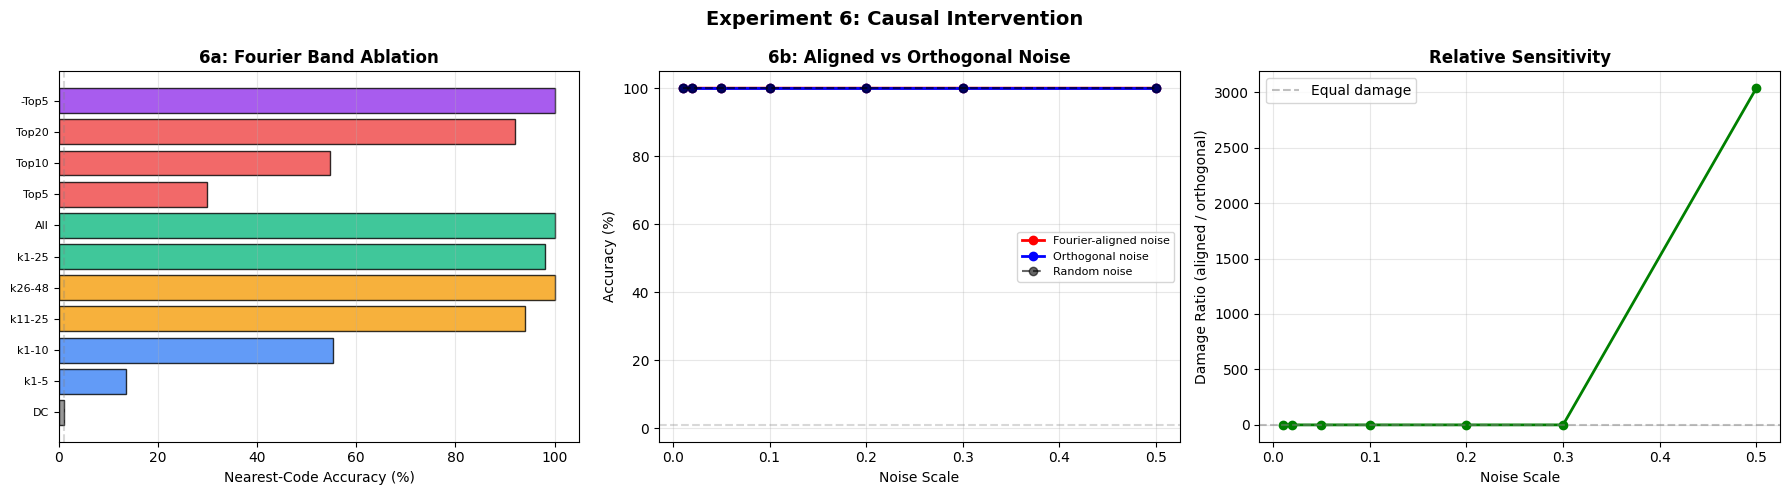


Experiment 6 Summary:
  At noise scale 0.1:
    Aligned noise:    100.0%
    Orthogonal noise: 100.0%
    Damage ratio:     0.00x
  → Similar sensitivity in all directions
    The model uses the full latent space, not just Fourier directions


In [11]:
# ── Experiment 6: Visualization ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Fourier band ablation
ax = axes[0]
band_names_short = ['DC', 'k1-5', 'k1-10', 'k11-25', 'k26-48', 'k1-25', 'All',
                     'Top5', 'Top10', 'Top20', '-Top5']
band_accs = [band_results[k]*100 for k in bands.keys()]
colors_band = ['gray'] + ['#3b82f6']*2 + ['#f59e0b']*2 + ['#10b981'] + ['#10b981'] + \
              ['#ef4444']*3 + ['#9333ea']
ax.barh(range(len(band_names_short)), band_accs, color=colors_band, alpha=0.8, edgecolor='black')
ax.set_yticks(range(len(band_names_short)))
ax.set_yticklabels(band_names_short, fontsize=8)
ax.set_xlabel('Nearest-Code Accuracy (%)')
ax.set_title('6a: Fourier Band Ablation', fontweight='bold')
ax.axvline(x=100/p, color='gray', linestyle='--', alpha=0.3)
ax.grid(alpha=0.3, axis='x')

# Panel 2: Noise injection
ax = axes[1]
ax.plot(noise_scales, [a*100 for a in results_aligned], 'r-o', linewidth=2, label='Fourier-aligned noise')
ax.plot(noise_scales, [a*100 for a in results_orthogonal], 'b-o', linewidth=2, label='Orthogonal noise')
ax.plot(noise_scales, [a*100 for a in results_random], 'k--o', linewidth=1.5, alpha=0.6, label='Random noise')
ax.axhline(y=100/p, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('Noise Scale')
ax.set_ylabel('Accuracy (%)')
ax.set_title('6b: Aligned vs Orthogonal Noise', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Panel 3: Damage ratio (aligned/orthogonal)
ax = axes[2]
damage_aligned = [100 - a*100 for a in results_aligned]
damage_ortho = [100 - a*100 for a in results_orthogonal]
damage_ratio = [a / (o + 1e-6) for a, o in zip(damage_aligned, damage_ortho)]
ax.plot(noise_scales, damage_ratio, 'g-o', linewidth=2)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Equal damage')
ax.set_xlabel('Noise Scale')
ax.set_ylabel('Damage Ratio (aligned / orthogonal)')
ax.set_title('Relative Sensitivity', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle('Experiment 6: Causal Intervention', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('exp6_causal_intervention.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nExperiment 6 Summary:')
mid_idx = noise_scales.index(0.1)
print(f'  At noise scale 0.1:')
print(f'    Aligned noise:    {results_aligned[mid_idx]*100:.1f}%')
print(f'    Orthogonal noise: {results_orthogonal[mid_idx]*100:.1f}%')
print(f'    Damage ratio:     {damage_ratio[mid_idx]:.2f}x')
if damage_ratio[mid_idx] > 2:
    print(f'  → Fourier-aligned directions are MUCH more sensitive')
    print(f'    The model causally relies on Fourier-structured components')
elif damage_ratio[mid_idx] > 1.2:
    print(f'  → Fourier-aligned directions are moderately more sensitive')
else:
    print(f'  → Similar sensitivity in all directions')
    print(f'    The model uses the full latent space, not just Fourier directions')

---
## Experiment 7: Task Variation

Train the same JEPA architecture on three different tasks:
1. **Modular multiplication** (a·b) mod 97
2. **Bitwise XOR** a ⊕ b (for a, b ∈ {0, ..., 96})
3. **Polynomial** (a² + b² + a·b) mod 97

For each: does grokking occur? How many epochs? What accuracy?

Training budget: 50K epochs per task (shorter than 100K for addition, but
addition grokked at 38K so 50K should be sufficient to detect grokking).

In [12]:
TASK_EPOCHS = 50_000
TASK_EVAL_EVERY = 500

def train_jepa_on_task(operation, num_classes, epochs=TASK_EPOCHS, eval_every=TASK_EVAL_EVERY):
    """Train JEPA from scratch on a given binary operation."""
    print(f'\nTraining JEPA on: {operation} (mod {p})')
    print(f'  Classes: {num_classes}, Epochs: {epochs}')
    
    # Generate data
    _, tgts, tr_pairs, tr_tgts, va_pairs, va_tgts = generate_data(p, operation)
    
    # Check number of unique classes
    actual_classes = tgts.unique().numel()
    print(f'  Unique target values: {actual_classes}')
    if actual_classes != num_classes:
        print(f'  WARNING: expected {num_classes} classes, got {actual_classes}')
        num_classes = actual_classes
    
    # Initialize fresh model
    ctx = ContextEncoder(p, LATENT_DIM, HIDDEN_DIM).to(device)
    tgt = TargetEncoder(num_classes, LATENT_DIM, HIDDEN_DIM).to(device)
    pred = Predictor(LATENT_DIM, PREDICTOR_DIM).to(device)
    tgt_ema = deepcopy(tgt)
    for param in tgt_ema.parameters():
        param.requires_grad = False
    
    opt = optim.AdamW(
        list(ctx.parameters()) + list(pred.parameters()) + list(tgt.parameters()),
        lr=LR, weight_decay=WEIGHT_DECAY
    )
    
    loader = DataLoader(TensorDataset(tr_pairs, tr_tgts),
                        batch_size=len(tr_pairs), shuffle=True)
    
    history = {
        'epoch': [], 'loss': [],
        'train_probe_acc': [], 'val_probe_acc': [],
        'train_nearest_acc': [], 'val_nearest_acc': [],
    }
    
    start = time.time()
    for epoch in range(epochs):
        ctx.train(); tgt.train(); pred.train()
        for bp, bt in loader:
            opt.zero_grad()
            z_ctx = ctx(bp)
            z_pred = pred(z_ctx)
            with torch.no_grad():
                z_tgt = tgt_ema(bt)
            loss = -(z_pred * z_tgt).sum(dim=-1).mean()
            loss.backward()
            opt.step()
            ema_update(tgt, tgt_ema, EMA_DECAY)
        
        if epoch % eval_every == 0 or epoch == epochs - 1:
            ctx.eval(); pred.eval()
            tr_probe, va_probe = linear_probe_accuracy(
                ctx, va_pairs, va_tgts, tr_pairs, tr_tgts, num_classes)
            tr_near = nearest_code_accuracy(ctx, pred, tgt_ema, tr_pairs, tr_tgts, num_classes)
            va_near = nearest_code_accuracy(ctx, pred, tgt_ema, va_pairs, va_tgts, num_classes)
            
            history['epoch'].append(epoch)
            history['loss'].append(loss.item())
            history['train_probe_acc'].append(tr_probe)
            history['val_probe_acc'].append(va_probe)
            history['train_nearest_acc'].append(tr_near)
            history['val_nearest_acc'].append(va_near)
        
        if epoch % (eval_every * 10) == 0 or epoch == epochs - 1:
            elapsed = (time.time() - start) / 60
            print(f'  Epoch {epoch:6d} [{elapsed:5.1f}m] | '
                  f'Probe: tr={tr_probe*100:.1f}% val={va_probe*100:.1f}% | '
                  f'Nearest: tr={tr_near*100:.1f}% val={va_near*100:.1f}%')
    
    elapsed = (time.time() - start) / 60
    print(f'  Complete in {elapsed:.1f} min.')
    
    # Detect grokking
    va_arr = np.array(history['val_probe_acc'])
    grok_mask = va_arr > 0.9
    grok_ep = np.array(history['epoch'])[grok_mask][0] if grok_mask.any() else None
    
    return {
        'history': history,
        'grok_epoch': grok_ep,
        'final_probe': history['val_probe_acc'][-1],
        'final_nearest': history['val_nearest_acc'][-1],
        'num_classes': num_classes,
    }

In [13]:
# ── Task 1: Modular Multiplication ─────────────────────────────────────
# Note: (a*b) mod p has p classes but class 0 is special (any a*0 = 0)
# This makes multiplication harder — less uniform class distribution
result_multiply = train_jepa_on_task('multiply', p)


Training JEPA on: multiply (mod 97)
  Classes: 97, Epochs: 50000
  Unique target values: 97
  Epoch      0 [  0.0m] | Probe: tr=18.8% val=2.1% | Nearest: tr=0.8% val=1.1%
  Epoch   5000 [  2.5m] | Probe: tr=100.0% val=2.4% | Nearest: tr=100.0% val=2.8%
  Epoch  10000 [  5.1m] | Probe: tr=99.6% val=2.5% | Nearest: tr=100.0% val=3.6%
  Epoch  15000 [  7.6m] | Probe: tr=99.6% val=3.2% | Nearest: tr=100.0% val=4.8%
  Epoch  20000 [ 10.1m] | Probe: tr=99.6% val=4.2% | Nearest: tr=100.0% val=6.3%
  Epoch  25000 [ 12.6m] | Probe: tr=99.8% val=6.9% | Nearest: tr=100.0% val=9.4%
  Epoch  30000 [ 15.1m] | Probe: tr=99.8% val=12.7% | Nearest: tr=100.0% val=13.4%
  Epoch  35000 [ 17.6m] | Probe: tr=99.9% val=30.6% | Nearest: tr=100.0% val=26.6%
  Epoch  40000 [ 20.2m] | Probe: tr=100.0% val=78.2% | Nearest: tr=100.0% val=73.4%
  Epoch  45000 [ 22.7m] | Probe: tr=100.0% val=99.9% | Nearest: tr=100.0% val=100.0%
  Epoch  49999 [ 25.2m] | Probe: tr=100.0% val=100.0% | Nearest: tr=100.0% val=100.0%
 

In [14]:
# ── Task 2: Bitwise XOR ────────────────────────────────────────────────
# XOR on integers 0..96. Number of unique outputs = max possible XOR value + 1
# For 7-bit numbers (96 < 128), XOR can produce values up to 127
xor_vals = set()
for a in range(p):
    for b in range(p):
        xor_vals.add(a ^ b)
n_xor_classes = max(xor_vals) + 1  # need embedding up to max value
print(f'XOR: {len(xor_vals)} unique outputs, max value = {max(xor_vals)}')
print(f'Target encoder needs vocab size = {n_xor_classes}')

# For XOR, target encoder needs larger vocab
# Override with custom training that handles this
result_xor = train_jepa_on_task('xor', n_xor_classes)

XOR: 128 unique outputs, max value = 127
Target encoder needs vocab size = 128

Training JEPA on: xor (mod 97)
  Classes: 128, Epochs: 50000
  Unique target values: 128
  Epoch      0 [  0.0m] | Probe: tr=28.1% val=0.0% | Nearest: tr=0.5% val=0.8%
  Epoch   5000 [  2.5m] | Probe: tr=99.2% val=4.5% | Nearest: tr=100.0% val=4.7%
  Epoch  10000 [  5.0m] | Probe: tr=99.8% val=48.3% | Nearest: tr=100.0% val=46.1%
  Epoch  15000 [  7.5m] | Probe: tr=100.0% val=99.1% | Nearest: tr=100.0% val=99.9%
  Epoch  20000 [ 10.1m] | Probe: tr=100.0% val=100.0% | Nearest: tr=100.0% val=100.0%
  Epoch  25000 [ 12.6m] | Probe: tr=100.0% val=100.0% | Nearest: tr=100.0% val=100.0%
  Epoch  30000 [ 15.1m] | Probe: tr=100.0% val=100.0% | Nearest: tr=100.0% val=100.0%
  Epoch  35000 [ 17.6m] | Probe: tr=100.0% val=100.0% | Nearest: tr=100.0% val=100.0%
  Epoch  40000 [ 20.1m] | Probe: tr=100.0% val=100.0% | Nearest: tr=100.0% val=100.0%
  Epoch  45000 [ 22.6m] | Probe: tr=100.0% val=100.0% | Nearest: tr=100.0%

In [15]:
# ── Task 3: Polynomial ─────────────────────────────────────────────────
# (a^2 + b^2 + a*b) mod 97 — still mod p, so p classes
result_poly = train_jepa_on_task('polynomial', p)


Training JEPA on: polynomial (mod 97)
  Classes: 97, Epochs: 50000
  Unique target values: 97
  Epoch      0 [  0.0m] | Probe: tr=28.1% val=0.4% | Nearest: tr=1.0% val=1.0%
  Epoch   5000 [  2.5m] | Probe: tr=98.9% val=0.9% | Nearest: tr=100.0% val=0.8%
  Epoch  10000 [  5.0m] | Probe: tr=98.4% val=0.6% | Nearest: tr=100.0% val=1.2%
  Epoch  15000 [  7.5m] | Probe: tr=97.4% val=0.8% | Nearest: tr=100.0% val=0.8%
  Epoch  20000 [ 10.0m] | Probe: tr=98.2% val=0.7% | Nearest: tr=100.0% val=1.1%
  Epoch  25000 [ 12.5m] | Probe: tr=97.8% val=0.9% | Nearest: tr=100.0% val=0.8%
  Epoch  30000 [ 15.0m] | Probe: tr=97.9% val=0.8% | Nearest: tr=100.0% val=0.9%
  Epoch  35000 [ 17.4m] | Probe: tr=98.1% val=0.8% | Nearest: tr=100.0% val=0.9%
  Epoch  40000 [ 19.9m] | Probe: tr=98.3% val=0.9% | Nearest: tr=100.0% val=1.0%
  Epoch  45000 [ 22.3m] | Probe: tr=97.7% val=0.9% | Nearest: tr=100.0% val=1.1%
  Epoch  49999 [ 24.7m] | Probe: tr=98.2% val=0.9% | Nearest: tr=100.0% val=1.2%
  Complete in 24

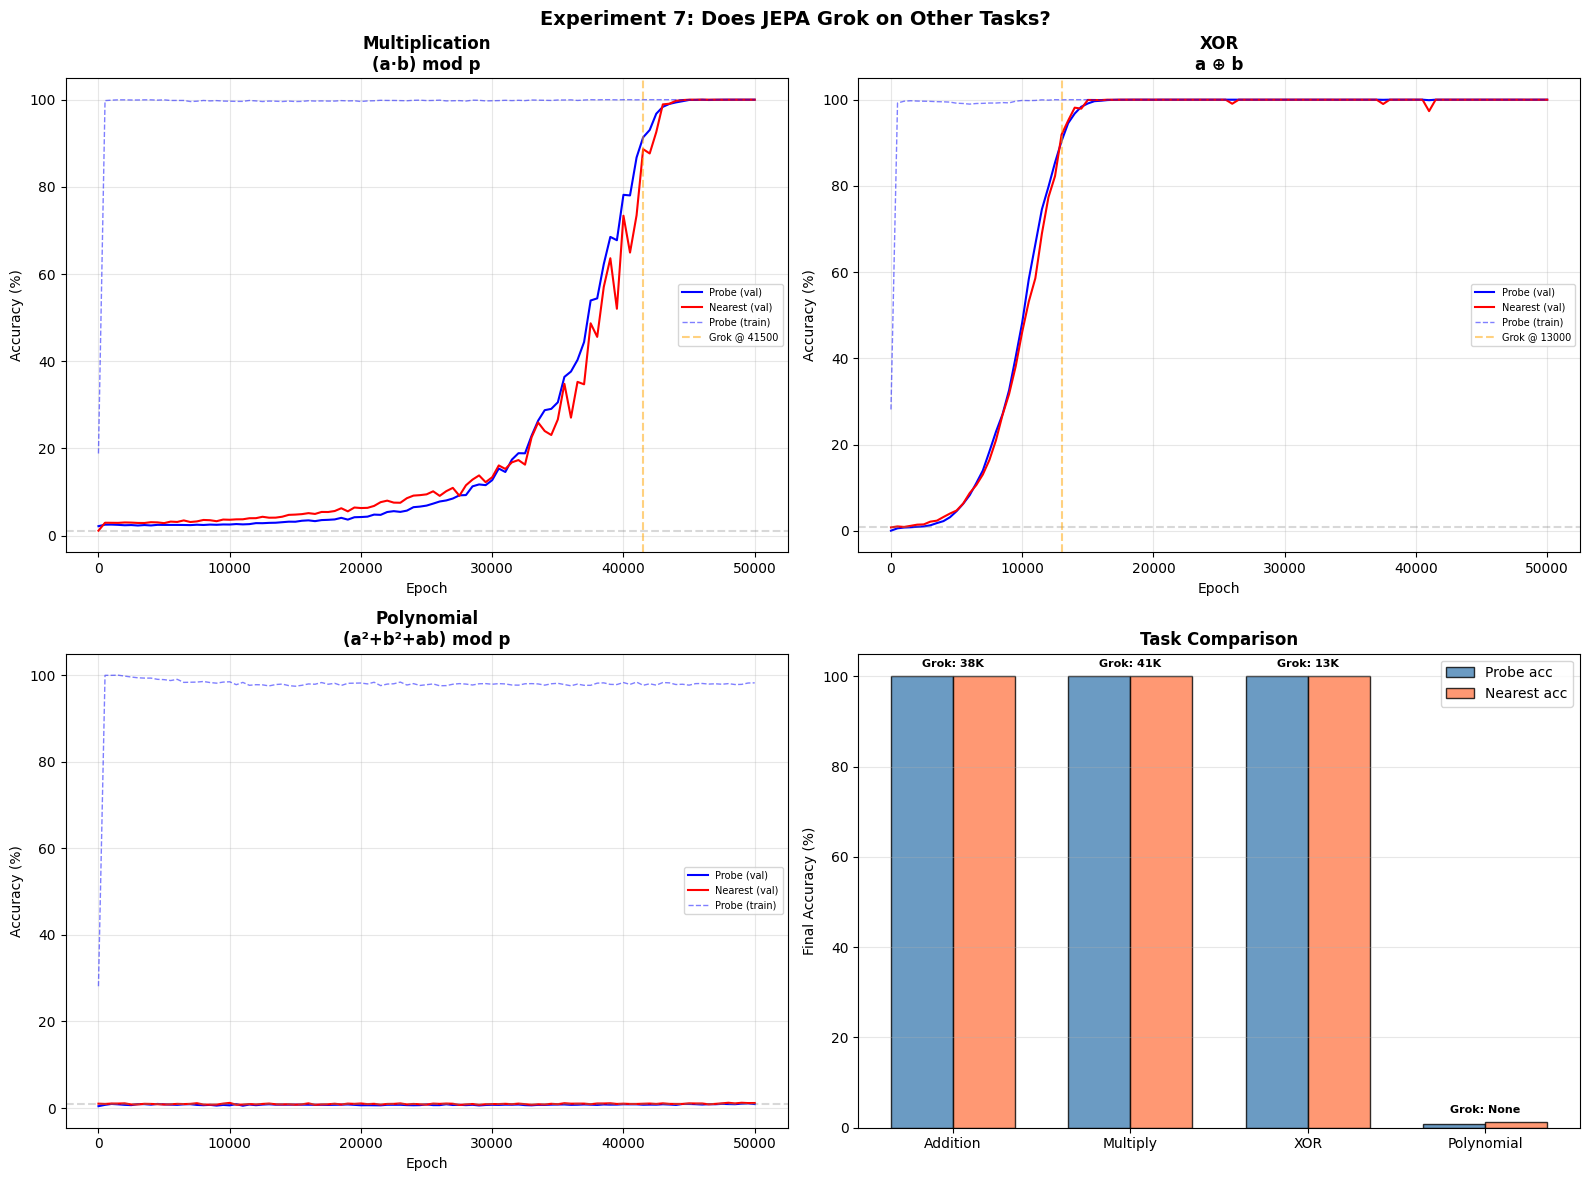

In [16]:
# ── Experiment 7: Visualization ─────────────────────────────────────────
task_results = {
    'Addition\n(a+b) mod p': None,  # from loaded checkpoint, not re-trained
    'Multiplication\n(a·b) mod p': result_multiply,
    'XOR\na ⊕ b': result_xor,
    'Polynomial\n(a²+b²+ab) mod p': result_poly,
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1-3: Learning curves for each new task
task_list = ['Multiplication\n(a·b) mod p', 'XOR\na ⊕ b', 'Polynomial\n(a²+b²+ab) mod p']
results_list = [result_multiply, result_xor, result_poly]
panel_positions = [(0, 0), (0, 1), (1, 0)]

for (task_name, result), (row, col) in zip(zip(task_list, results_list), panel_positions):
    ax = axes[row, col]
    h = result['history']
    ep = np.array(h['epoch'])
    
    ax.plot(ep, [a*100 for a in h['val_probe_acc']], 'b-', linewidth=1.5, label='Probe (val)')
    ax.plot(ep, [a*100 for a in h['val_nearest_acc']], 'r-', linewidth=1.5, label='Nearest (val)')
    ax.plot(ep, [a*100 for a in h['train_probe_acc']], 'b--', linewidth=1, alpha=0.5, label='Probe (train)')
    
    chance = 100 / result['num_classes']
    ax.axhline(y=chance, color='gray', linestyle='--', alpha=0.3)
    
    if result['grok_epoch'] is not None:
        ax.axvline(x=result['grok_epoch'], color='orange', linestyle='--', alpha=0.5,
                   label=f'Grok @ {result["grok_epoch"]}')
    
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(task_name, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

# Panel 4: Summary comparison
ax = axes[1, 1]
all_tasks = ['Addition', 'Multiply', 'XOR', 'Polynomial']
all_probe = [100.0, result_multiply['final_probe']*100,
             result_xor['final_probe']*100, result_poly['final_probe']*100]
all_nearest = [100.0, result_multiply['final_nearest']*100,
               result_xor['final_nearest']*100, result_poly['final_nearest']*100]
all_grok = ['38K', 
            f'{result_multiply["grok_epoch"]//1000}K' if result_multiply['grok_epoch'] else 'None',
            f'{result_xor["grok_epoch"]//1000}K' if result_xor['grok_epoch'] else 'None',
            f'{result_poly["grok_epoch"]//1000}K' if result_poly['grok_epoch'] else 'None']

x = np.arange(len(all_tasks))
w = 0.35
ax.bar(x - w/2, all_probe, w, color='steelblue', alpha=0.8, label='Probe acc', edgecolor='black')
ax.bar(x + w/2, all_nearest, w, color='coral', alpha=0.8, label='Nearest acc', edgecolor='black')

# Annotate grokking epoch
for i, g in enumerate(all_grok):
    ax.annotate(f'Grok: {g}', xy=(i, max(all_probe[i], all_nearest[i]) + 2),
                ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(all_tasks)
ax.set_ylabel('Final Accuracy (%)')
ax.set_title('Task Comparison', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.suptitle('Experiment 7: Does JEPA Grok on Other Tasks?', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('exp7_task_variation.png', dpi=150, bbox_inches='tight')
plt.show()

## Combined Summary

In [17]:
print('='*70)
print('COMBINED SUMMARY: Experiments 5, 6, 7')
print('='*70)

print(f'\n--- Experiment 5: Function Approximation ---')
print(f'  Class-mean prediction alignment: {cos_mean_vs_target.mean().item():.4f}')
print(f'  Target code Fourier spectrum: {"flat (no structure)" if tc_mean_power_norm[1:p//2+1].std() < 0.005 else "non-uniform"}')
print(f'  Phase coherence: {phase_coherence.mean():.3f}')
for thr in [0.90, 0.95, 0.99]:
    mask = acc_arr >= thr
    if mask.any():
        n_min = n_components_list[np.where(mask)[0][0]]
        print(f'  Components for {thr:.0%} reconstruction accuracy: {n_min}')

print(f'\n--- Experiment 6: Causal Intervention ---')
mid_idx = noise_scales.index(0.1)
print(f'  Fourier-aligned subspace: {n_aligned_dims} / {LATENT_DIM} dimensions')
print(f'  At noise=0.1: aligned={results_aligned[mid_idx]*100:.1f}%, '
      f'orthogonal={results_orthogonal[mid_idx]*100:.1f}%, '
      f'ratio={damage_ratio[mid_idx]:.2f}x')
print(f'  Band ablation: top-10 freqs → {band_results["Top-10 by power"]*100:.1f}%, '
      f'all freqs → {band_results["All (k=0..48)"]*100:.1f}%')

print(f'\n--- Experiment 7: Task Variation ---')
print(f'{"Task":>20s} | {"Grok?":>8s} | {"Grok @":>8s} | {"Probe":>7s} | {"Nearest":>7s}')
print(f'{"-"*20}-+-{"-"*8}-+-{"-"*8}-+-{"-"*7}-+-{"-"*7}')
for task_name, result, grok_str in [
    ('Addition', None, '38K'),
    ('Multiplication', result_multiply, None),
    ('XOR', result_xor, None),
    ('Polynomial', result_poly, None),
]:
    if result is None:
        print(f'{task_name:>20s} | {"✓":>8s} | {grok_str:>8s} | {100.0:>6.1f}% | {100.0:>6.1f}%')
    else:
        grokked = '✓' if result['grok_epoch'] else '✗'
        grok_ep = f'{result["grok_epoch"]//1000}K' if result['grok_epoch'] else 'N/A'
        print(f'{task_name:>20s} | {grokked:>8s} | {grok_ep:>8s} | '
              f'{result["final_probe"]*100:>6.1f}% | {result["final_nearest"]*100:>6.1f}%')

# Overall verdict
n_grokked = sum(1 for r in [result_multiply, result_xor, result_poly] if r['grok_epoch'] is not None)
print(f'\n  Tasks that grokked: {n_grokked + 1}/4 (including addition)')
if n_grokked >= 2:
    print(f'  → JEPA grokking generalizes across multiple algebraic tasks!')
    print(f'    This is NOT specific to modular addition.')
elif n_grokked == 1:
    print(f'  → JEPA grokking extends to some but not all tasks.')
    print(f'    Task structure matters.')
else:
    print(f'  → JEPA grokking appears SPECIFIC to modular addition.')
    print(f'    The finding may not generalize.')

print(f'\n{"="*70}')

COMBINED SUMMARY: Experiments 5, 6, 7

--- Experiment 5: Function Approximation ---
  Class-mean prediction alignment: 0.9733
  Target code Fourier spectrum: flat (no structure)
  Phase coherence: 0.089
  Components for 90% reconstruction accuracy: 18
  Components for 95% reconstruction accuracy: 22
  Components for 99% reconstruction accuracy: 24

--- Experiment 6: Causal Intervention ---
  Fourier-aligned subspace: 34 / 128 dimensions
  At noise=0.1: aligned=100.0%, orthogonal=100.0%, ratio=0.00x
  Band ablation: top-10 freqs → 54.7%, all freqs → 100.0%

--- Experiment 7: Task Variation ---
                Task |    Grok? |   Grok @ |   Probe | Nearest
---------------------+----------+----------+---------+--------
            Addition |        ✓ |      38K |  100.0% |  100.0%
      Multiplication |        ✓ |      41K |  100.0% |  100.0%
                 XOR |        ✓ |      13K |  100.0% |  100.0%
          Polynomial |        ✗ |      N/A |    0.9% |    1.2%

  Tasks that grokked: